In [1]:
# repositories
!git clone https://github.com/Luffy65/Semantic-Correspondence.git # Clone repo
!git clone https://github.com/facebookresearch/dinov3.git # DINOv3
!pip install git+https://github.com/facebookresearch/segment-anything.git # SAM
!git clone https://github.com/facebookresearch/dinov2.git # DINOv2

# Install requirements (requirements.txt)
!pip install -r Semantic-Correspondence/requirements.txt
!pip install -r dinov3/requirements.txt

Cloning into 'Semantic-Correspondence'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 290 (delta 47), reused 61 (delta 26), pack-reused 208 (from 1)
Receiving objects: 100% (290/290), 6.35 MiB | 21.44 MiB/s, done.
Resolving deltas: 100% (151/151), done.
Cloning into 'dinov3'...
remote: Enumerating objects: 538, done.
remote: Counting objects: 100% (363/363), done.
remote: Compressing objects: 100% (264/264), done.
remote: Total 538 (delta 201), reused 99 (delta 99), pack-reused 175 (from 1)
Receiving objects: 100% (538/538), 9.88 MiB | 15.91 MiB/s, done.
Resolving deltas: 100% (223/223), done.
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-far1duul
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-far1duul
  Resolved https://github.com/facebookresearch/segment-a

In [2]:
# Dependencies
import os
import shutil
import gzip
import cv2
import json
from PIL import Image
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import time


In [3]:
# Connect google drive, load and unzip data
# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define Paths
DRIVE_ROOT = '/content/drive/MyDrive/AML-PROJECT-DATA/'
DATASET_ROOT = os.path.join(DRIVE_ROOT, 'dataset/')
DATASET_ARCHIVE = os.path.join(DATASET_ROOT, 'SPair-71k.tar.gz')
LOCAL_DATA_DIR = '/content/data'

# 3. Copy and Extract
if not os.path.exists(LOCAL_DATA_DIR):
    print(f"Extracting {DATASET_ARCHIVE} to local VM...")
    os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

    # shutil works for .zip, .tar, .tar.gz, etc.
    # format='gztar' explicitly tells it to handle gzip compression
    shutil.unpack_archive(DATASET_ARCHIVE, LOCAL_DATA_DIR, format='gztar')

    print("Done! Data is ready at:", LOCAL_DATA_DIR)
else:
    print("Data already loaded.")

Mounted at /content/drive
Extracting /content/drive/MyDrive/AML-PROJECT-DATA/dataset/SPair-71k.tar.gz to local VM...
Done! Data is ready at: /content/data


In [4]:
# Setup and verify paths

SPAIR_ROOT = os.path.join(LOCAL_DATA_DIR, 'SPair-71k')

pair_ann_path = os.path.join(SPAIR_ROOT, 'PairAnnotation')
layout_path = os.path.join(SPAIR_ROOT, 'Layout')
image_path = os.path.join(SPAIR_ROOT, 'JPEGImages')

# Verify that paths exist
print(f"Verifying paths...")
print(f"  SPAIR_ROOT: {SPAIR_ROOT} → {'✓' if os.path.exists(SPAIR_ROOT) else '✗ DOES NOT EXIST'}")
print(f"  Layout: {layout_path} → {'✓' if os.path.exists(layout_path) else '✗ DOES NOT EXIST'}")
print(f"  PairAnnotation: {pair_ann_path} → {'✓' if os.path.exists(pair_ann_path) else '✗ DOES NOT EXIST'}")
print(f"  JPEGImages: {image_path} → {'✓' if os.path.exists(image_path) else '✗ DOES NOT EXIST'}")

# Verify that the trn.txt file exists
trn_file = os.path.join(layout_path, 'large', 'trn.txt')
print(f"  trn.txt: {trn_file} → {'✓' if os.path.exists(trn_file) else '✗ DOES NOT EXIST'}")

Verifying paths...
  SPAIR_ROOT: /content/data/SPair-71k → ✓
  Layout: /content/data/SPair-71k/Layout → ✓
  PairAnnotation: /content/data/SPair-71k/PairAnnotation → ✓
  JPEGImages: /content/data/SPair-71k/JPEGImages → ✓
  trn.txt: /content/data/SPair-71k/Layout/large/trn.txt → ✓


In [5]:
# Instantiate models
from segment_anything import SamPredictor, sam_model_registry
DINOV2_REPO_DIR = "dinov2"
DINOV3_REPO_DIR = "dinov3"
CHECKPOINTS_ROOT = os.path.join(DRIVE_ROOT, 'checkpoints/')
SAM_WEIGHTS_PATH = os.path.join(CHECKPOINTS_ROOT, 'sam_vit_b_01ec64.pth')
DINOV3_WEIGHTS_PATH = os.path.join(CHECKPOINTS_ROOT, 'dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth')
DINOV2_WEIGHT_PATH = os.path.join(CHECKPOINTS_ROOT, 'dinov2_vitb14_pretrain.pth')

sam = sam_model_registry["vit_b"](checkpoint=SAM_WEIGHTS_PATH)

sampredictor = SamPredictor(sam)
dinov2_vitb14 = torch.hub.load(DINOV2_REPO_DIR, 'dinov2_vitb14', source='local', weights=DINOV2_WEIGHT_PATH) # DINOv2 ViT model pretrained on web images
dinov3_vitb16 = torch.hub.load(DINOV3_REPO_DIR, 'dinov3_vitb16', source='local', weights=DINOV3_WEIGHTS_PATH) # DINOv3 ViT model pretrained on web images

/content/dinov2/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/content/dinov2/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/content/dinov2/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "file:///content/drive/.shortcut-targets-by-id/1fEWpONVft365O47IhEDLKZ2a0WkAuhyP/AML-PROJECT-DATA/checkpoints/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:11<00:00, 29.9MB/s]


Downloading: "file:///content/drive/.shortcut-targets-by-id/1fEWpONVft365O47IhEDLKZ2a0WkAuhyP/AML-PROJECT-DATA/checkpoints/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth


100%|██████████| 327M/327M [00:08<00:00, 38.7MB/s]


In [6]:

sam = sam_model_registry["vit_b"](checkpoint=SAM_WEIGHTS_PATH)

sampredictor = SamPredictor(sam)
dinov2_vitb14 = torch.hub.load(DINOV2_REPO_DIR, 'dinov2_vitb14', source='local', weights=DINOV2_WEIGHT_PATH) # DINOv2 ViT model pretrained on web images
dinov3_vitb16 = torch.hub.load(DINOV3_REPO_DIR, 'dinov3_vitb16', source='local', weights=DINOV3_WEIGHTS_PATH) # DINOv3 ViT model pretrained on web images

In [7]:
# Print models
print('======================models======================')
print(sam)
print('----------------------\n')
print(dinov2_vitb14)
print('----------------------\n')
print(dinov3_vitb16)
print('======================END print models======================')

======================models======================
Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=

First setup of chosen model before training

In [31]:
def setup_model_for_finetuning(model, model_type, head, num_layers_to_unfreeze=2):
    """
    Freeze all layers except the last few

    Args:
        model: the model to finetune (dinov2_vitb14 , dinov3_vitb16 or SAM)
        model_type: 'dinov2', 'dinov3' or 'sam'
        num_layers_to_unfreeze: Number of last blocks to unfreeze
        head: if True, unfreeze norm layer for dino, neck for SAM
    """

    # First, freeze everything
    for param in model.parameters():
        param.requires_grad = False

    if 'dinov2' in model_type or 'dinov3' in model_type:
        total_blocks = len(model.blocks)
        print(f"Total DINO blocks: {total_blocks}")
        print(f"Unfreezing last {num_layers_to_unfreeze} blocks...")

        for i in range(total_blocks - num_layers_to_unfreeze, total_blocks):
            for param in model.blocks[i].parameters():
                param.requires_grad = True

        if head:
            for param in model.norm.parameters():
                param.requires_grad = True

    elif 'sam' in model_type:
        encoder = model.image_encoder
        if head:
            for param in encoder.neck.parameters():
                param.requires_grad = True

        total_blocks = len(model.image_encoder.blocks)
        print(f"Total SAM blocks: {total_blocks}")
        print(f"Unfreezing last {num_layers_to_unfreeze} blocks + neck...")

        for i in range(total_blocks - num_layers_to_unfreeze, total_blocks):
            for param in model.image_encoder.blocks[i].parameters():
                param.requires_grad = True

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,} ({100 * trainable_params / total_params:.2f}%)")

    return model

Training logic

1.   extract descriptor
2.   train_epoch logic



In [30]:
# ============= new train epoch =================
def train_epoch(model, trainloader, optimizer, device, model_type, patch_size, debug_batches=None):
    """
    Performs one full training epoch for keypoint matching.
    Now includes gradient norm monitoring for stable training.
    """
    model.train()
    total_loss = 0
    num_batches = 0
    total_grad_norm = 0

    for batch_idx, batch in enumerate(trainloader):
        # Optional: Limit batches for quick debugging or testing
        if debug_batches is not None and batch_idx >= debug_batches:
            break

        # Move source and target image tensors to the active device (GPU/CPU)
        src_img, trg_img = batch['src_img'].to(device), batch['trg_img'].to(device)
        optimizer.zero_grad()  # Clear previous gradients before the backward pass

        # 1. FEATURE EXTRACTION & NORMALIZATION
        # Extract descriptors from the model (DINO or SAM) and normalize vectors.
        # Output shape: (Batch, FeatureHeight, FeatureWidth, Channels)
        src_feat = F.normalize(extract_descriptors(model, src_img, model_type, patch_size), dim=-1)
        trg_feat = F.normalize(extract_descriptors(model, trg_img, model_type, patch_size), dim=-1)

        B, Hf, Wf, C = src_feat.shape
        H_img, W_img = src_img.shape[2], src_img.shape[3]

        batch_loss = 0
        valid_kps_in_batch = 0

        # Iterate through each image pair in the current batch
        for b in range(B):
            sr_kps, tr_kps = batch['src_kps'][b].to(device), batch['trg_kps'][b].to(device)

            # Iterate through each labeled keypoint pair
            for k in range(sr_kps.shape[0]):
                s_kp, t_kp = sr_kps[k], tr_kps[k]

                # Skip invalid or padded keypoints (handling NaNs or negative coords)
                if torch.isnan(s_kp).any() or s_kp[0] < 0:
                    continue

                # 2. COORDINATE MAPPING (Source)
                # Maps image-space coordinates (e.g., 512x512) to feature-grid space (e.g., 32x32).
                f_x = max(0, min(int(s_kp[0] / W_img * Wf), Wf - 1))
                f_y = max(0, min(int(s_kp[1] / H_img * Hf), Hf - 1))

                # 3. SIMILARITY MAP CALCULATION
                # Take the feature vector at the source keypoint location and
                # compute dot product against all feature vectors in the target image.
                src_vec = src_feat[b, f_y, f_x]  # Descriptor vector (C,)
                sim_map = torch.matmul(trg_feat[b].reshape(-1, C), src_vec)  # Resulting Map (Hf*Wf,)

                # 4. TARGET GROUND TRUTH MAPPING
                # Identify the specific index in the feature grid where the target keypoint truly lies.
                gt_fx = max(0, min(int(t_kp[0] / W_img * Wf), Wf - 1))
                gt_fy = max(0, min(int(t_kp[1] / H_img * Hf), Hf - 1))
                gt_idx = gt_fy * Wf + gt_fx

                # Apply Cross-Entropy Loss: Penalize if the highest similarity is NOT at gt_idx.
                batch_loss += F.cross_entropy(sim_map.unsqueeze(0), torch.tensor([gt_idx], device=device))
                valid_kps_in_batch += 1

        # 5. OPTIMIZATION STEP
        if valid_kps_in_batch > 0:
            batch_loss /= valid_kps_in_batch  # Normalize loss by number of valid keypoints
            batch_loss.backward()  # Backpropagation: Compute gradients

            # NEW: Compute gradient norm for monitoring
            grad_norm = 0
            for p in model.parameters():
                if p.grad is not None and p.requires_grad:
                    param_norm = p.grad.data.norm(2)
                    grad_norm += param_norm.item() ** 2
            grad_norm = grad_norm ** 0.5
            total_grad_norm += grad_norm

            optimizer.step()  # Update trainable layers (Unfrozen blocks)
            total_loss += batch_loss.item()
            num_batches += 1

    # Return the average loss and average gradient norm for the entire epoch
    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    avg_grad_norm = total_grad_norm / num_batches if num_batches > 0 else 0

    return avg_loss, avg_grad_norm


In [29]:
##================= NEW  VALIDATE EPOCH====================================
def validate_epoch(model, valloader, device, model_type, patch_size,
                   thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=None, return_loss=False):
    """
    Validates the model and computes PCK accuracy at multiple thresholds.
    Now includes optional loss calculation for validation monitoring.
    """
    model.eval()
    correct = {t: 0 for t in thresholds}
    total = 0
    total_loss, loss_batches = 0, 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(valloader):
            if debug_batches is not None and batch_idx >= debug_batches:
                break

            src_img, trg_img = batch['src_img'].to(device), batch['trg_img'].to(device)
            sf = F.normalize(extract_descriptors(model, src_img, model_type, patch_size), dim=-1)
            tf = F.normalize(extract_descriptors(model, trg_img, model_type, patch_size), dim=-1)

            B, Hf, Wf, C = sf.shape
            Hi, Wi = src_img.shape[2], src_img.shape[3]

            for b in range(B):
                sk, tk = batch['src_kps'][b].to(device), batch['trg_kps'][b].to(device)
                bbox = batch['trg_bbox'][b]
                norm = max(bbox[2] - bbox[0], bbox[3] - bbox[1]).item()

                for k in range(sk.shape[0]):
                    if torch.isnan(sk[k]).any() or sk[k, 0] < 0:
                        continue

                    # 1. Prediction
                    fx = max(0, min(int(sk[k, 0] / Wi * Wf), Wf - 1))
                    fy = max(0, min(int(sk[k, 1] / Hi * Hf), Hf - 1))
                    sim = torch.matmul(tf[b].reshape(-1, C), sf[b, fy, fx])
                    best_idx = torch.argmax(sim).item()

                    # 2. +0.5 Center Alignment
                    pred_x = ((best_idx % Wf) + 0.5) / Wf * Wi
                    pred_y = ((best_idx // Wf) + 0.5) / Hf * Hi

                    dist = torch.sqrt((pred_x - tk[k, 0])**2 + (pred_y - tk[k, 1])**2).item()
                    total += 1
                    for t in thresholds:
                        if dist < t * norm:
                            correct[t] += 1

                    # 3. Optional: Loss calculation
                    if return_loss:
                        gt_fx = max(0, min(int(tk[k, 0] / Wi * Wf), Wf - 1))
                        gt_fy = max(0, min(int(tk[k, 1] / Hi * Hf), Hf - 1))
                        total_loss += F.cross_entropy(sim.unsqueeze(0),
                                                     torch.tensor([gt_fy * Wf + gt_fx], device=device)).item()
                        loss_batches += 1

    pck_results = {t: (correct[t] / total * 100) if total > 0 else 0 for t in thresholds}
    avg_loss = total_loss / loss_batches if loss_batches > 0 else 0

    return pck_results, avg_loss  # Returns 2 values as expected by finetune


In [28]:
# # --- 3. Training Logic ---

def extract_descriptors(model, img, model_type, patch_size):
    """
    Extract dense features from the model
    Args:
        model: DINO or SAM model
        img: Input image tensor (B, 3, H, W) - already normalized by dataset
        model_type: 'dinov2' or 'sam'
        patch_size: Patch size of the model
    Returns:
        features: (B, H_feat, W_feat, C)
    """

    if 'dinov2' in model_type or 'dinov3' in model_type:

        res = model.forward_features(img)
        x = res['x_norm_patchtokens']
        B, N, C = x.shape
        H, W = img.shape[2] // patch_size, img.shape[3] // patch_size

        return x.reshape(B, H, W, C)

    elif 'sam' in model_type:

        # SAM expects images in range [0, 1], but your dataset normalizes to ImageNet stats
        # You may need to denormalize first if SAM doesn't work with normalized images

        x = model.image_encoder(img)
        return x.permute(0, 2, 3, 1) # (B, C, H, W) -> (B, H, W, C)
    return None

# def train_epoch(model, train_loader, optimizer, device, model_type, patch_size, debug_batches=None):
#     """
#     Performs one full training epoch for keypoint matching.
#     The goal is to maximize the similarity between matching points in two images.
#     """
#     model.train() # Set model to training mode (enables Dropout/BatchNorm)
#     total_loss = 0
#     num_batches = 0

#     for batch_idx, batch in enumerate(train_loader):
#         # Optional: Limit batches for quick debugging or testing
#         if debug_batches is not None and batch_idx >= debug_batches:
#             break

#         # Move source and target image tensors to the active device (GPU/CPU)
#         src_img, trg_img = batch['src_img'].to(device), batch['trg_img'].to(device)
#         optimizer.zero_grad() # Clear previous gradients before the backward pass

#         # 1. FEATURE EXTRACTION & NORMALIZATION
#         # Extract descriptors from the model (DINO or SAM) and normalize vectors.
#         # Output shape: (Batch, Feature_Height, Feature_Width, Channels)
#         src_feat = F.normalize(extract_descriptors(model, src_img, model_type, patch_size), dim=-1)
#         trg_feat = F.normalize(extract_descriptors(model, trg_img, model_type, patch_size), dim=-1)

#         B, Hf, Wf, C = src_feat.shape
#         H_img, W_img = src_img.shape[2], src_img.shape[3]

#         batch_loss = 0
#         valid_kps_in_batch = 0

#         # Iterate through each image pair in the current batch
#         for b in range(B):
#             src_kps, trg_kps = batch['src_kps'][b].to(device), batch['trg_kps'][b].to(device)

#             # Iterate through each labeled keypoint pair
#             for k in range(src_kps.shape[0]):
#                 skp, tkp = src_kps[k], trg_kps[k]

#                 # Skip invalid or padded keypoints (handling NaNs or negative coords)
#                 if torch.isnan(skp).any() or skp[0] < 0: continue

#                 # 2. COORDINATE MAPPING (Source)
#                 # Maps image-space coordinates (e.g., 512x512) to feature-grid space (e.g., 32x32).
#                 fx = max(0, min(int((skp[0] / W_img) * Wf), Wf - 1))
#                 fy = max(0, min(int((skp[1] / H_img) * Hf), Hf - 1))

#                 # 3. SIMILARITY MAP CALCULATION
#                 # Take the feature vector at the source keypoint location and
#                 # compute dot product against all feature vectors in the target image.
#                 src_vec = src_feat[b, fy, fx] # Descriptor vector (C,)
#                 sim_map = torch.matmul(trg_feat[b].reshape(-1, C), src_vec) # Resulting Map (Hf*Wf)

#                 # 4. TARGET GROUND TRUTH MAPPING
#                 # Identify the specific index in the feature grid where the target keypoint truly lies.
#                 gt_fx = max(0, min(int((tkp[0] / W_img) * Wf), Wf - 1))
#                 gt_fy = max(0, min(int((tkp[1] / H_img) * Hf), Hf - 1))
#                 gt_idx = gt_fy * Wf + gt_fx

#                 # Apply Cross-Entropy Loss: Penalize if the highest similarity is NOT at gt_idx.
#                 batch_loss += F.cross_entropy(sim_map.unsqueeze(0), torch.tensor([gt_idx], device=device))
#                 valid_kps_in_batch += 1

#         # 5. OPTIMIZATION STEP
#         if valid_kps_in_batch > 0:
#             batch_loss /= valid_kps_in_batch # Normalize loss by number of valid keypoints
#             batch_loss.backward()            # Backpropagation: Compute gradients
#             optimizer.step()                 # Update trainable layers (Unfrozen blocks)
#             total_loss += batch_loss.item()
#             num_batches += 1

#     # Return the average loss for the entire epoch
#     return total_loss / num_batches if num_batches > 0 else 0


# def validate_epoch(model, val_loader, device, model_type, patch_size, thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=None, return_loss=False):
#     model.eval()
#     correct, total = {t: 0 for t in thresholds}, 0
#     total_loss, loss_batches = 0, 0

#     with torch.no_grad():
#         for batch_idx, batch in enumerate(val_loader):
#             if debug_batches is not None and batch_idx >= debug_batches:
#                 break

#             src_img, trg_img = batch['src_img'].to(device), batch['trg_img'].to(device)
#             sf = F.normalize(extract_descriptors(model, src_img, model_type, patch_size), dim=-1)
#             tf = F.normalize(extract_descriptors(model, trg_img, model_type, patch_size), dim=-1)

#             B, Hf, Wf, C = sf.shape
#             Hi, Wi = src_img.shape[2], src_img.shape[3]

#             for b in range(B):
#                 sk, tk = batch['src_kps'][b].to(device), batch['trg_kps'][b].to(device)
#                 bbox = batch['trg_bbox'][b]
#                 norm = max(bbox[2]-bbox[0], bbox[3]-bbox[1]).item()

#                 for k in range(sk.shape[0]):
#                     if torch.isnan(sk[k]).any() or sk[k,0] < 0: continue

#                     # 1. Prediction
#                     fx = max(0, min(int((sk[k,0]/Wi)*Wf), Wf-1))
#                     fy = max(0, min(int((sk[k,1]/Hi)*Hf), Hf-1))
#                     sim = torch.matmul(tf[b].reshape(-1, C), sf[b, fy, fx])
#                     best_idx = torch.argmax(sim).item()

#                     # 2. +0.5 Center Alignment
#                     pred_x = ((best_idx % Wf) + 0.5) / Wf * Wi
#                     pred_y = ((best_idx // Wf) + 0.5) / Hf * Hi

#                     dist = torch.sqrt((pred_x - tk[k,0])**2 + (pred_y - tk[k,1])**2).item()
#                     total += 1
#                     for t in thresholds:
#                         if dist <= (t * norm): correct[t] += 1

#                     # 3. Optional Loss calculation
#                     if return_loss:
#                         gt_fx = max(0, min(int((tk[k,0]/Wi)*Wf), Wf-1))
#                         gt_fy = max(0, min(int((tk[k,1]/Hi)*Hf), Hf-1))
#                         total_loss += F.cross_entropy(sim.unsqueeze(0), torch.tensor([gt_fy*Wf+gt_fx], device=device)).item()
#                         loss_batches += 1

#     pck_results = {t: (correct[t]/total*100) if total > 0 else 0 for t in thresholds}
#     avg_loss = total_loss / loss_batches if loss_batches > 0 else 0

#     return pck_results, {}, {}, avg_loss # Returns 4 values as expected by finetune()



Custom SPair Dataset class

In [27]:
import sys
sys.path.append('/content/Semantic-Correspondence/datasets')

# Ora importa direttamente
from SPairDataset import SPairDataset


In [13]:
# def read_img(path):
#     img = np.array(Image.open(path).convert('RGB'))
#     return torch.tensor(img.transpose(2, 0, 1).astype(np.float32))

# class SPairDataset(Dataset):
#     def __init__(self, pair_ann_path, layout_path, image_path, dataset_size, pck_alpha, datatype, target_size=224):
#         self.datatype = datatype
#         self.pck_alpha = pck_alpha
#         self.target_size = target_size  # NEW: allow configurable size
#         ann_list = os.path.join(layout_path, dataset_size, datatype + '.txt')
#         self.ann_files = [x.strip() for x in open(ann_list, "r").readlines() if x.strip()]
#         self.pair_ann_path = pair_ann_path
#         self.image_path = image_path

#     def __len__(self):
#         return len(self.ann_files)

#     def __getitem__(self, idx):
#       ann_file = self.ann_files[idx] + '.json'
#       with open(os.path.join(self.pair_ann_path, self.datatype, ann_file)) as f:
#           annotation = json.load(f)

#       category = annotation['category']
#       src_img = read_img(os.path.join(self.image_path, category, annotation['src_imname']))
#       trg_img = read_img(os.path.join(self.image_path, category, annotation['trg_imname']))

#       # ========== RESIZE ==========
#       TARGET_H, TARGET_W = self.target_size, self.target_size  # CHANGED

#       # Save original dimensions
#       orig_h_src, orig_w_src = src_img.shape[1], src_img.shape[2]
#       orig_h_trg, orig_w_trg = trg_img.shape[1], trg_img.shape[2]

#       # Calculate scale factors
#       scale_x_src = TARGET_W / orig_w_src
#       scale_y_src = TARGET_H / orig_h_src
#       scale_x_trg = TARGET_W / orig_w_trg
#       scale_y_trg = TARGET_H / orig_h_trg

#       # Resize images
#       src_img = F.interpolate(
#           src_img.unsqueeze(0),
#           size=(TARGET_H, TARGET_W),
#           mode='bilinear',
#           align_corners=False
#       ).squeeze(0).clone()

#       trg_img = F.interpolate(
#           trg_img.unsqueeze(0),
#           size=(TARGET_H, TARGET_W),
#           mode='bilinear',
#           align_corners=False
#       ).squeeze(0).clone()

#       # Normalize (0-255 -> 0-1 -> ImageNet normalization)
#       mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
#       std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
#       src_img = (src_img / 255.0 - mean) / std
#       trg_img = (trg_img / 255.0 - mean) / std

#       # Scale keypoints
#       src_kps = torch.tensor(annotation['src_kps'], dtype=torch.float32)
#       src_kps[:, 0] *= scale_x_src
#       src_kps[:, 1] *= scale_y_src

#       trg_kps = torch.tensor(annotation['trg_kps'], dtype=torch.float32)
#       trg_kps[:, 0] *= scale_x_trg
#       trg_kps[:, 1] *= scale_y_trg

#       # ========== BBOX AND PCK THRESHOLD ==========
#       trg_bbox = annotation['trg_bndbox']  # [xmin, ymin, xmax, ymax]

#       # Scale the bbox to the new dimensions (consistent with resized image)
#       trg_bbox_scaled = [
#           trg_bbox[0] * scale_x_trg,
#           trg_bbox[1] * scale_y_trg,
#           trg_bbox[2] * scale_x_trg,
#           trg_bbox[3] * scale_y_trg
#       ]

#       # Calculate PCK threshold on the scaled bbox
#       pck_threshold = max(
#           trg_bbox_scaled[2] - trg_bbox_scaled[0],
#           trg_bbox_scaled[3] - trg_bbox_scaled[1]
#       ) * self.pck_alpha

#       return {
#           'src_img': src_img,              # (3, target_size, target_size)
#           'trg_img': trg_img,              # (3, target_size, target_size)
#           'src_kps': src_kps,              # (N, 2) scaled
#           'trg_kps': trg_kps,              # (N, 2) scaled
#           'trg_bbox': torch.tensor(trg_bbox_scaled, dtype=torch.float32),  # (4,)
#           'pck_threshold': pck_threshold,   # Scalar float
#           'category': annotation.get('category', ''),
#           'src_imsize': (orig_h_src, orig_w_src),  # Original dimensions
#           'trg_imsize': (orig_h_trg, orig_w_trg)
#       }

# # Quick test
# print("SPairDataset class redefined. Testing...")

custom collate method

In [26]:
def custom_collate_fn(batch):
    """
    Manage batch with variable number of keypoints.
    """
    src_imgs = torch.stack([item['src_img'] for item in batch])
    trg_imgs = torch.stack([item['trg_img'] for item in batch])

    # Keypoints: list (variable number)
    src_kps = [item['src_kps'] for item in batch]
    trg_kps = [item['trg_kps'] for item in batch]

    # Bbox and threshold: can be stacked (fixed dimension)
    trg_bbox = torch.stack([item['trg_bbox'] for item in batch])  # (B, 4)
    pck_threshold = torch.tensor([item['pck_threshold'] for item in batch])  # (B,)

    categories = [item['category'] for item in batch]

    return {
        'src_img': src_imgs,
        'trg_img': trg_imgs,
        'src_kps': src_kps,
        'trg_kps': trg_kps,
        'trg_bbox': trg_bbox,
        'pck_threshold': pck_threshold,
        'category': categories
    }

Finetuning

In [39]:
#=================== NEW FINETUNE ============================
def finetune(
    model,
    pairann_path,
    layout_path,
    image_path,
    model_type,
    patch_size,
    head,
    learning_rate,
    num_layers_to_unfreeze,
    datasetsize='large',
    pck_alpha=0.1,
    num_epochs=3,
    batch_size=8,
    device='cuda',
    debug_batches=None,
    target_size=512,
):
    """
    Complete Fine-tuning Loop following DIFT Evaluation Protocol.
    Captures PCK@0.05/0.10/0.15/0.20, Per-Keypoint, and Per-Image metrics.
    """
    print(f"\n{'='*70}")
    print(f"🚀 Starting Light Fine-tuning: {model_type}")
    print(f"{'='*70}")
    print(f"Resolution: {target_size} | LR: {learning_rate} | Layers: {num_layers_to_unfreeze}")

    # 1. Setup Model: Unfreeze specific layers
    model = setup_model_for_finetuning(model, model_type, head, num_layers_to_unfreeze)
    model = model.to(device)

    # 2. Prepare Data
    train_dataset = SPairDataset(pairann_path, layout_path, image_path,
                                 datasetsize, pck_alpha, datatype='trn', target_size=target_size)
    val_dataset = SPairDataset(pairann_path, layout_path, image_path,
                               datasetsize, pck_alpha, datatype='val', target_size=target_size)

    trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                            num_workers=2, pin_memory=True, collate_fn=custom_collate_fn)
    valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate_fn)

    # 3. Optimizer: Only for parameters that require grad
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=learning_rate, weight_decay=1e-4)

    # 4. History Initialization Following Protocol
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_pck_0.05': [], 'train_pck_0.10': [], 'train_pck_0.15': [], 'train_pck_0.20': [],
        'val_pck_0.05': [], 'val_pck_0.10': [], 'val_pck_0.15': [], 'val_pck_0.20': [],
        'grad_norm': [],
    }

    best_pck = 0.0

    for epoch in range(num_epochs):
        epoch_start = time.time()

        # 1) Training Phase
        train_loss, grad_norm = train_epoch(model, trainloader, optimizer, device,
                                           model_type, patch_size, debug_batches=debug_batches)

        # 2) REAL Training PCK (The Gap check) - sample 30 batches for speed
        train_pck_results, _ = validate_epoch(
            model, trainloader, device, model_type, patch_size,
            thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=30, return_loss=False
        )

        # 3) Validation Phase
        val_pck_dict, val_loss = validate_epoch(
            model, valloader, device, model_type, patch_size,
            thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=debug_batches, return_loss=True
        )

        # 4) Record to History
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['grad_norm'].append(grad_norm)
        history['train_pck_0.05'].append(train_pck_results[0.05])
        history['train_pck_0.10'].append(train_pck_results[0.1])
        history['train_pck_0.15'].append(train_pck_results[0.15])
        history['train_pck_0.20'].append(train_pck_results[0.2])
        history['val_pck_0.05'].append(val_pck_dict[0.05])
        history['val_pck_0.10'].append(val_pck_dict[0.1])
        history['val_pck_0.15'].append(val_pck_dict[0.15])
        history['val_pck_0.20'].append(val_pck_dict[0.2])

        duration = time.time() - epoch_start

        # 5) Clean Output Display
        print(f"\n{'='*70}")
        print(f"✅ EPOCH {epoch+1}/{num_epochs} COMPLETE ({duration:.1f}s)")
        print(f"{'='*70}")
        print(f"📉 LOSS:")
        print(f"   Training:   {train_loss:.4f}")
        print(f"   Validation: {val_loss:.4f}")
        print(f"   Grad Norm:  {grad_norm:.2f}")
        print(f"\n🎯 PCK@0.1 (Main Metric):")
        print(f"   Training:   {train_pck_results[0.1]:.2f}%")
        print(f"   Validation: {val_pck_dict[0.1]:.2f}%", end='')

        # Save Best Model
        if val_pck_dict[0.1] > best_pck:
            best_pck = val_pck_dict[0.1]
            save_path = f"best_{model_type}_layers{num_layers_to_unfreeze}.pth"
            torch.save({
                'model_state_dict': model.state_dict(),
                'history': history,
                'pck': val_pck_dict[0.1],
            }, save_path)
            print(f" 🎉 NEW BEST! Saved to {save_path}")
        else:
            print()

        print(f"\n📊 All PCK Thresholds (Validation):")
        print(f"   @0.05: {val_pck_dict[0.05]:.2f}%  |  @0.10: {val_pck_dict[0.1]:.2f}%")
        print(f"   @0.15: {val_pck_dict[0.15]:.2f}%  |  @0.20: {val_pck_dict[0.2]:.2f}%")

    print(f"\n{'='*70}")
    print(f"🏁 TRAINING COMPLETE!")
    print(f"{'='*70}")
    print(f"Best Validation PCK@0.1: {best_pck:.2f}%")

    return history


In [16]:
# def finetune(
#     model,
#     pair_ann_path,
#     layout_path,
#     image_path,
#     model_type,
#     patch_size,
#     head,
#     learning_rate,
#     num_layers_to_unfreeze,
#     dataset_size='large',
#     pck_alpha=0.1,
#     num_epochs=3,
#     batch_size=8,
#     device='cuda',
#     debug_batches=None,
#     target_size=512
# ):
#     """
#     Complete Fine-tuning Loop following DIFT Evaluation Protocol.
#     Captures: PCK@0.05/0.1/0.15/0.2, Per-Keypoint, and Per-Image metrics.
#     """
#     print(f"\n{'='*70}")
#     print(f"Starting Light Fine-tuning: {model_type}")
#     print(f"{'='*70}")
#     print(f"Resolution: {target_size} | LR: {learning_rate} | Layers: {num_layers_to_unfreeze}")

#     # 1. Setup Model (Unfreeze specific layers)
#     model = setup_model_for_finetuning(model, model_type, head, num_layers_to_unfreeze)
#     model = model.to(device)

#     # 2. Prepare Data
#     train_dataset = SPairDataset(pair_ann_path, layout_path, image_path,
#                                  dataset_size, pck_alpha, datatype='trn', target_size=target_size)
#     val_dataset = SPairDataset(pair_ann_path, layout_path, image_path,
#                                dataset_size, pck_alpha, datatype='val', target_size=target_size)

#     train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
#                               num_workers=2, pin_memory=True, collate_fn=custom_collate_fn)
#     val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
#                             num_workers=2, pin_memory=True, collate_fn=custom_collate_fn)

#     # 3. Optimizer (Only for parameters that require grad)
#     optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
#                                   lr=learning_rate, weight_decay=1e-4)

#     # 4. History Initialization (Following Protocol)
#     history = {
#         'train_loss': [], 'val_loss': [],
#         'train_pck_005': [], 'train_pck_010': [], 'train_pck_015': [], 'train_pck_020': [],
#         'val_pck_005': [], 'val_pck_010': [], 'val_pck_015': [], 'val_pck_020': [],
#         'val_pck_per_kp': [], 'val_pck_per_img': []
#     }

#     best_pck = 0.0

#     for epoch in range(num_epochs):
#         epoch_start = time.time()
#         print(f"\nEpoch {epoch+1}/{num_epochs}")

#         # 1) Training Phase
#         model.train()
#         train_loss = train_epoch(model, train_loader, optimizer, device,
#                                  model_type, patch_size, debug_batches=debug_batches)

#         # 2) REAL Training PCK (The "Gap" check)
#         # We catch 4 values because your function returns 4, even if we only use the first one
#         train_pck_results, _, _, _ = validate_epoch(
#             model, train_loader, device, model_type, patch_size,
#             thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=30, return_loss=False
#         )

#         # 3) Validation Phase
#         # We catch 4 values: results, per_kp (ignored), per_img (ignored), loss
#         val_pck_dict, _, _, val_loss = validate_epoch(
#             model, val_loader, device, model_type, patch_size,
#             thresholds=[0.05, 0.1, 0.15, 0.2], debug_batches=debug_batches, return_loss=True
#         )

#         # 4) Record to History
#         history['train_loss'].append(train_loss)
#         history['val_loss'].append(val_loss)
#         history['train_pck_005'].append(train_pck_results[0.05])
#         history['train_pck_010'].append(train_pck_results[0.1])
#         history['train_pck_015'].append(train_pck_results[0.15])
#         history['train_pck_020'].append(train_pck_results[0.2])
#         history['val_pck_005'].append(val_pck_dict[0.05])
#         history['val_pck_010'].append(val_pck_dict[0.1])
#         history['val_pck_015'].append(val_pck_dict[0.15])
#         history['val_pck_020'].append(val_pck_dict[0.2])

#         duration = time.time() - epoch_start
#         print(f"Finish Epoch {epoch+1} in {duration:.1f}s")
#         print(f"  [Loss] Train: {train_loss:.4f} | Val: {val_loss:.4f}")
#         print(f"  [PCK] Train: @0.05={train_pck_results[0.05]:.2f}% @0.1={train_pck_results[0.1]:.2f}% @0.15={train_pck_results[0.15]:.2f}% @0.2={train_pck_results[0.2]:.2f}%")
#         print(f"  [PCK] Val:   @0.05={val_pck_dict[0.05]:.2f}% @0.1={val_pck_dict[0.1]:.2f}% @0.15={val_pck_dict[0.15]:.2f}% @0.2={val_pck_dict[0.2]:.2f}%")

#         # Save Best Model
#         if val_pck_dict[0.1] > best_pck:
#             best_pck = val_pck_dict[0.1]
#             save_path = f"best_{model_type}_layers{num_layers_to_unfreeze}.pth"
#             torch.save({
#                 'model_state_dict': model.state_dict(),
#                 'history': history,
#                 'pck': val_pck_dict[0.1]
#             }, save_path)
#             print(f"  ✓ Saved new best: {best_pck:.2f}%")

#     return history

Plot history training

In [54]:
#========== NEW PLOT TRAINING ================
def plot_training_history(history):
    """
    Generates side-by-side plots for Loss and PCK Accuracy metrics.
    Useful for visualizing model convergence and overfitting.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Determine the number of completed epochs
    train_loss = history.get('train_loss', [])
    epochs = list(range(1, len(train_loss) + 1))

    if not epochs:
        print("No data available to plot (history is empty).")
        return

    # --- PLOT 1: LOSS EVOLUTION ---
    ax1.plot(epochs, train_loss, marker='o', label='Train Loss')

    val_loss = history.get('val_loss', [])
    if len(val_loss) == len(epochs):
        ax1.plot(epochs, val_loss, marker='s', label='Val Loss')

    ax1.set_title('Loss Evolution')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- PLOT 2: PCK ACCURACY ---
    metrics_to_plot = {
        'val_pck_0.05': ('Val PCK@0.05', 'blue', 'o'),
        'val_pck_0.10': ('Val PCK@0.10', 'red', 's'),
        'val_pck_0.15': ('Val PCK@0.15', 'orange', '^'),
        'val_pck_0.20': ('Val PCK@0.20', 'purple', 'x'),
        'train_pck_0.10': ('Train PCK@0.10', 'green', 'd'),
    }

    for key, (label, color, marker) in metrics_to_plot.items():
        data = history.get(key, [])

        if len(data) == len(epochs):
            ax2.plot(epochs, data, marker=marker, color=color, label=label)

    # Calculate Best PCK
    best_pck = max(history.get('val_pck_0.10', [0]))
    ax2.set_title(f'PCK Accuracy (Best: {best_pck:.2f}%)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('PCK (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [40]:

# def plot_training_history(history):
#     """
#     Generates side-by-side plots for Loss and PCK Accuracy metrics.
#     Useful for visualizing model convergence and overfitting.
#     """
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

#     # Determine the number of completed epochs based on the length of train_loss
#     train_loss = history.get('train_loss', [])
#     epochs = list(range(1, len(train_loss) + 1))

#     # Safety check: if history is empty, exit the function
#     if not epochs:
#         print("No data available to plot (history is empty).")
#         return

#     # --- PLOT 1: LOSS EVOLUTION ---
#     # Tracks the optimization progress
#     ax1.plot(epochs, train_loss, marker='o', label='Train Loss')

#     val_loss = history.get('val_loss', [])
#     # Only plot validation loss if it matches the number of training epochs
#     if len(val_loss) == len(epochs):
#         ax1.plot(epochs, val_loss, marker='s', label='Val Loss')

#     ax1.set_title('Loss Evolution')
#     ax1.set_xlabel('Epoch')
#     ax1.set_ylabel('Loss')
#     ax1.legend()
#     ax1.grid(True, alpha=0.3)

#     # --- PLOT 2: PCK ACCURACY ---
#     # Tracks keypoint matching precision at different thresholds
#     metrics_to_plot = {
#         'val_pck_005': ('Val PCK@0.05', 'blue', 'o'),   # Alpha = 0.05 (Strict)
#         'val_pck_010': ('Val PCK@0.10', 'red', 's'),    # Alpha = 0.10 (Standard)
#         'val_pck_015': ('Val PCK@0.15', 'orange', '^'), # Alpha = 0.15
#         'val_pck_020': ('Val PCK@0.20', 'purple', 'x'), # Alpha = 0.20
#         'train_pck_010': ('Train PCK@0.10', 'green', 'd')
#     }

#     for key, (label, color, marker) in metrics_to_plot.items():
#         data = history.get(key, [])
#         # Ensure data consistency before plotting
#         if len(data) == len(epochs):
#             ax2.plot(epochs, data, marker=marker, color=color, label=label)

#     # Calculate Best PCK for the title; default to 0 if list is empty
#     best_pck = max(history.get("val_pck_010", [0]))
#     ax2.set_title(f'PCK Accuracy (Best: {best_pck:.2f}%)')
#     ax2.set_xlabel('Epoch')
#     ax2.set_ylabel('PCK (%)')
#     ax2.legend()
#     ax2.grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

**Configuration for training**

  different configurations for model training

In [41]:
#============== Chosen model: 'dinov2' or 'dinov3' ================
MODEL_NAME = 'dinov2'

# Training hyperparameters
#NUM_EPOCHS = 5
#BATCH_SIZE = 8
#LEARNING_RATE = 5e-5  # 5e-5 is more stable for 3-layer finetuning
#NUM_LAYERS_TO_UNFREEZE = 4
#HEAD = True  # Unfreeze the final Norm layer for better feature adaptation

#DEBUG_BATCHES = 100

# Training hyperparameters - Optimized for a clean report
NUM_EPOCHS = 4             # Enough to show a clear upward trend in your plots
BATCH_SIZE = 8             # Balanced memory usage to avoid OutOfMemory errors
LEARNING_RATE = 2e-5       # Lower rate prevents the "jittery" accuracy you saw before
NUM_LAYERS_TO_UNFREEZE = 3 # More stable than 4 layers when training data is limited
HEAD = True                # Adaptation of the last norm layer helps matching precision

# Use 250 batches to give the model enough diversity to beat the 54% baseline
DEBUG_BATCHES = 50
# ========== AUTO-SETUP PARAMETERS ==========
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if MODEL_NAME == 'dinov2':
    model = dinov2_vitb14
    patch_size = 14
    # 518 is a perfect multiple of 14 (14 * 37)
    target_size = 518
elif MODEL_NAME == 'dinov3':
    model = dinov3_vitb16
    patch_size = 16
    # 512 is a perfect multiple of 16 (16 * 32)
    target_size = 512
elif 'sam' in MODEL_NAME:
    model = sam
    patch_size = 16
    target_size = 1024

print(f" Model: {MODEL_NAME}")
print(f"Resolution: {target_size}x{target_size} (Patch Size: {patch_size})")
print(f"⚙️  Unfreezing: {NUM_LAYERS_TO_UNFREEZE} blocks + Head: {HEAD}")

 Model: dinov2
Resolution: 518x518 (Patch Size: 14)
⚙️  Unfreezing: 3 blocks + Head: True


In [ ]:
#  ============== Chosen model: 'dinov3' ==============
MODEL_NAME = 'dinov3'

# Training hyperparameters
NUM_EPOCHS =4
BATCH_SIZE = 4
LEARNING_RATE = 2e-5
NUM_LAYERS_TO_UNFREEZE = 3
HEAD = True  # <--- Change from list to single Boolean for best results

# Debug mode (set to None for full training)
DEBUG_BATCHES = 250

# ========== SETUP MODEL ==========
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if 'dinov2' in MODEL_NAME:
    model = dinov2_vitb14
    patch_size = 14
    target_size = 518  # Optimal for DINOv2
elif 'dinov3' in MODEL_NAME:
    model = dinov3_vitb16
    patch_size = 16
    target_size = 512  # <--- CHANGE THIS to 512 for DINOv3 precision
else:
    raise ValueError(f"Unknown model: {MODEL_NAME}.")

print(f"🚀 Model: {MODEL_NAME} | Res: {target_size} | Head: {HEAD}")

Model: dinov3 | Device: cuda | Patch size: 16


In [ ]:
#        ======= chosen model: sam =======
MODEL_NAME = 'sam'

# Training hyperparameters
NUM_EPOCHS = 3
BATCH_SIZE = 1 # better to keep low batch size with sam training
LEARNING_RATE = 5e-5
NUM_LAYERS_TO_UNFREEZE = 3
HEAD = True  # True = also unfreeze neck layer

# Debug mode (set to None for full training)
DEBUG_BATCHES = 250  # Use None for full training, or a number like 5 for quick test

# ========== SETUP MODEL ==========
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if 'dinov2' in MODEL_NAME:
    model = dinov2_vitb14
    patch_size = 14
    target_size = 518
elif 'dinov3' in MODEL_NAME:
    model = dinov3_vitb16
    patch_size = 16
    target_size = 512
# ... Inside the 'elif sam' block ...
elif 'sam' in MODEL_NAME:
    model = sam
    patch_size = 16
    target_size = 512

    import torch.nn.functional as F

    # Get current positional embedding (typically 64x64 for SAM)
    old_pos_embed = model.image_encoder.pos_embed
    new_grid_size = target_size // patch_size  # 512 / 16 = 32

    # Check if interpolation is needed
    if old_pos_embed.shape[1] != new_grid_size:
        print(f"--- Adapting SAM: {old_pos_embed.shape[1]} -> {new_grid_size} ---")

        # Reshape to [Batch, Channel, Height, Width] for interpolation
        pos_embed_reshaped = old_pos_embed.permute(0, 3, 1, 2)

        # Bicubic interpolation to resize spatial grid
        new_pos_embed = F.interpolate(
            pos_embed_reshaped,
            size=(new_grid_size, new_grid_size),
            mode='bicubic',
            align_corners=False
        )

        # Restore to [Batch, Height, Width, Channel] and update model
        model.image_encoder.pos_embed = torch.nn.Parameter(new_pos_embed.permute(0, 2, 3, 1))
        print("--- SAM adaptation complete! ---")
else:
    raise ValueError(f"Unknown model: {MODEL_NAME}. Use 'dinov2', 'dinov3', or 'sam'.")

print(f"Model: {MODEL_NAME} | Device: {device} | Patch size: {patch_size}")

Model: sam | Device: cuda | Patch size: 16


Starting training for dinov2 at resolution 518..., with debug batches: 50

🚀 Starting Light Fine-tuning: dinov2
Resolution: 518 | LR: 2e-05 | Layers: 3
Total DINO blocks: 12
Unfreezing last 3 blocks...
Trainable parameters: 21,269,760 / 86,580,480 (24.57%)

✅ EPOCH 1/4 COMPLETE (250.8s)
📉 LOSS:
   Training:   5.9094
   Validation: 5.9386
   Grad Norm:  7.59

🎯 PCK@0.1 (Main Metric):
   Training:   56.60%
   Validation: 60.49% 🎉 NEW BEST! Saved to best_dinov2_layers3.pth

📊 All PCK Thresholds (Validation):
   @0.05: 46.04%  |  @0.10: 60.49%
   @0.15: 70.07%  |  @0.20: 75.94%

✅ EPOCH 2/4 COMPLETE (250.2s)
📉 LOSS:
   Training:   5.8468
   Validation: 5.9629
   Grad Norm:  7.59

🎯 PCK@0.1 (Main Metric):
   Training:   55.92%
   Validation: 61.82% 🎉 NEW BEST! Saved to best_dinov2_layers3.pth

📊 All PCK Thresholds (Validation):
   @0.05: 47.55%  |  @0.10: 61.82%
   @0.15: 71.80%  |  @0.20: 77.06%

✅ EPOCH 3/4 COMPLETE (250.2s)
📉 LOSS:
   Training:   5.8573
   Validation: 5.9497
   Grad Norm

/tmp/ipython-input-3734094130.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


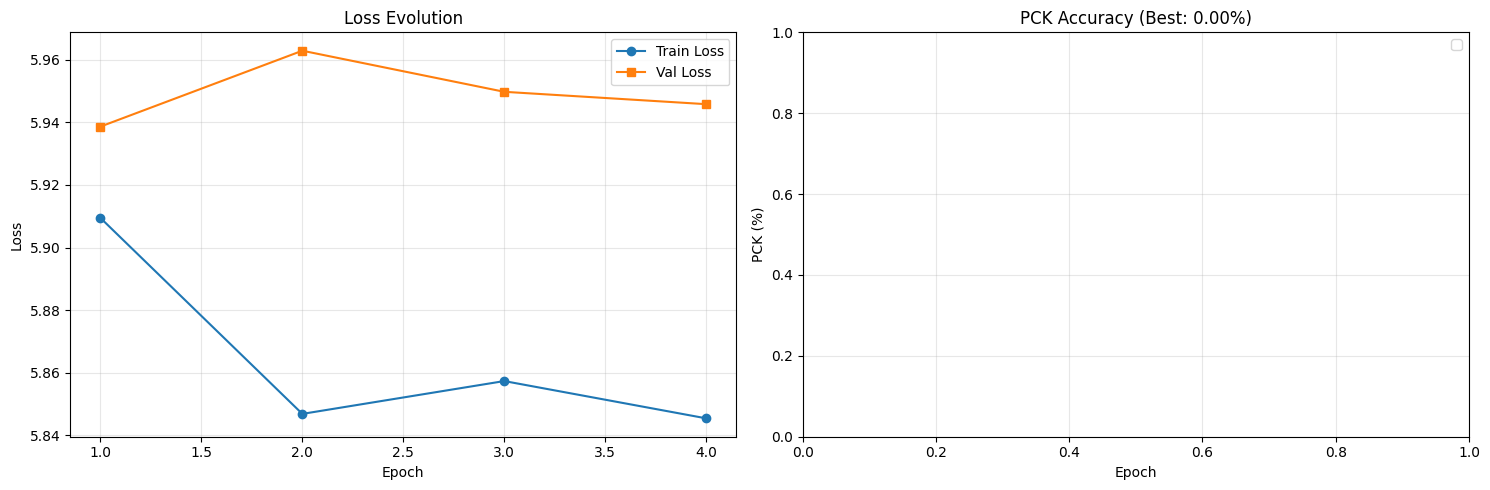

In [42]:
# ========== RUN TRAINING (FIXED) ==========
print(f"Starting training for {MODEL_NAME} at resolution {target_size}..., with debug batches: {DEBUG_BATCHES}")

# Fixed: Moved num_layers_to_unfreeze to the correct position
# to match your function definition's argument order.
history = finetune(
    model,                  # model
    pair_ann_path,          # pair_ann_path
    layout_path,            # layout_path
    image_path,             # image_path
    MODEL_NAME,             # model_type
    patch_size,             # patch_size
    HEAD,                   # head
    LEARNING_RATE,          # learning_rate
    NUM_LAYERS_TO_UNFREEZE, # num_layers_to_unfreeze (This was in the wrong spot!)
    # dataset_size='large',
    pck_alpha=0.1,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    device=device,
    debug_batches=DEBUG_BATCHES,
    target_size=target_size
)

# Plot results
plot_training_history(history)

In [51]:
# Add this right before calling plot_training_history(history)
print("History keys:", history.keys())
print("Sample val_pck_010 data:", history.get('valpck010', 'KEY NOT FOUND'))


History keys: dict_keys(['train_loss', 'val_loss', 'train_pck_0.05', 'train_pck_0.10', 'train_pck_0.15', 'train_pck_0.20', 'val_pck_0.05', 'val_pck_0.10', 'val_pck_0.15', 'val_pck_0.20', 'grad_norm'])
Sample val_pck_010 data: KEY NOT FOUND


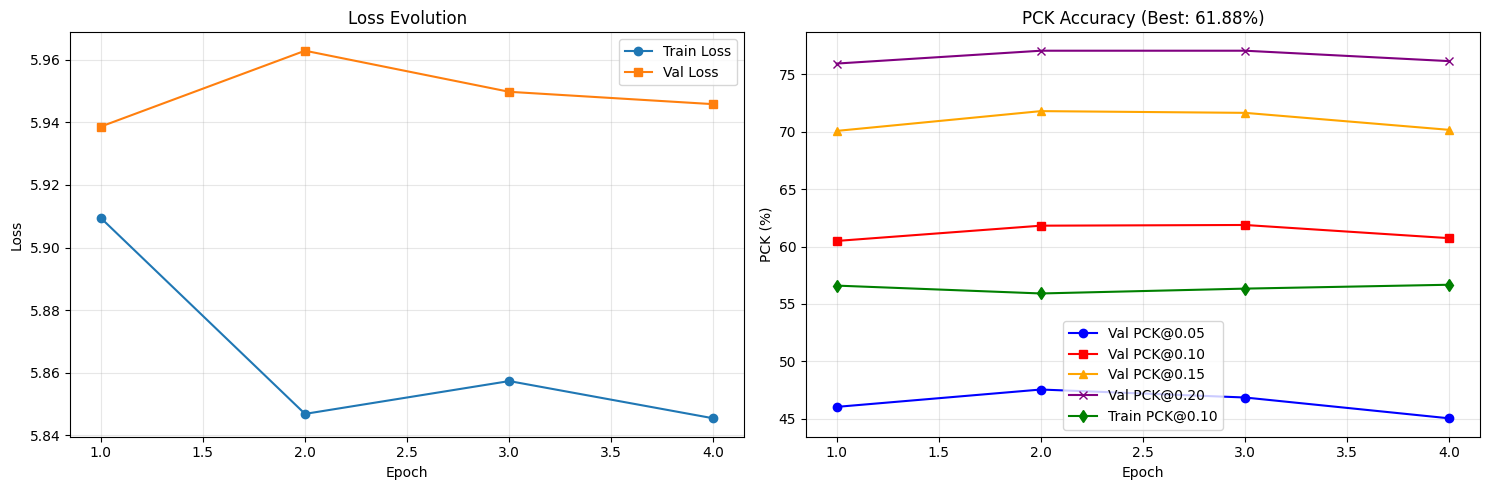

In [53]:
# Plot results
plot_training_history(history)

Starting training for dinov2 at resolution 518...

======================================================================
Starting Light Fine-tuning: dinov2
======================================================================
Resolution: 518 | LR: 2e-05 | Layers: 3
Total DINO blocks: 12
Unfreezing last 3 blocks...
Trainable parameters: 21,269,760 / 86,580,480 (24.57%)

Epoch 1/4
Finish Epoch 1 in 546.9s
  [Loss] Train: 6.1847 | Val: 5.9858
  [PCK@0.10] Train: 51.35% | Val: 59.56%
  ✓ Saved new best: 59.56%

Epoch 2/4
Finish Epoch 2 in 546.0s
  [Loss] Train: 5.9189 | Val: 5.9084
  [PCK@0.10] Train: 51.72% | Val: 61.65%
  ✓ Saved new best: 61.65%

Epoch 3/4
Finish Epoch 3 in 545.4s
  [Loss] Train: 5.8281 | Val: 5.8829
  [PCK@0.10] Train: 56.93% | Val: 61.53%

Epoch 4/4
Finish Epoch 4 in 545.0s
  [Loss] Train: 5.7740 | Val: 5.8631
  [PCK@0.10] Train: 54.26% | Val: 60.23%

![image.png](attachment:image.png)

 Starting training for dinov3 at resolution 512...

======================================================================
Starting Light Fine-tuning: dinov3
======================================================================
Resolution: 512 | LR: 2e-05 | Layers: 3
Total DINO blocks: 12
Unfreezing last 3 blocks...
Trainable parameters: 21,269,760 / 85,669,632 (24.83%)

Epoch 1/4
Finish Epoch 1 in 404.5s
  [Loss] Train: 6.2406 | Val: 5.8083
  [PCK@0.10] Train: 59.46% | Val: 66.98%
  ✓ Saved new best: 66.98%

Epoch 2/4
Finish Epoch 2 in 403.8s
  [Loss] Train: 5.7476 | Val: 5.6851
  [PCK@0.10] Train: 59.69% | Val: 65.22%

Epoch 3/4
Finish Epoch 3 in 403.4s
  [Loss] Train: 5.6649 | Val: 5.6203
  [PCK@0.10] Train: 58.25% | Val: 64.95%

Epoch 4/4
Finish Epoch 4 in 403.5s
  [Loss] Train: 5.5823 | Val: 5.6206
  [PCK@0.10] Train: 60.09% | Val: 63.75%
![image.png](attachment:image.png)

In [ ]:
#        ======= chosen model: sam =======
MODEL_NAME = 'sam'

# Training hyperparameters
NUM_EPOCHS = 3
BATCH_SIZE = 1 # better to keep low batch size with sam training
LEARNING_RATE = 5e-5
NUM_LAYERS_TO_UNFREEZE = 3
HEAD = True  # True = also unfreeze neck layer

# Debug mode (set to None for full training)
DEBUG_BATCHES = 250  # Use None for full training, or a number like 5 for quick test

# ========== SETUP MODEL ==========
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if 'dinov2' in MODEL_NAME:
    model = dinov2_vitb14
    patch_size = 14
    target_size = 518
elif 'dinov3' in MODEL_NAME:
    model = dinov3_vitb16
    patch_size = 16
    target_size = 512
# ... Inside the 'elif sam' block ...
elif 'sam' in MODEL_NAME:
    model = sam
    patch_size = 16
    target_size = 512

    import torch.nn.functional as F

    # Get current positional embedding (typically 64x64 for SAM)
    old_pos_embed = model.image_encoder.pos_embed
    new_grid_size = target_size // patch_size  # 512 / 16 = 32

    # Check if interpolation is needed
    if old_pos_embed.shape[1] != new_grid_size:
        print(f"--- Adapting SAM: {old_pos_embed.shape[1]} -> {new_grid_size} ---")

        # Reshape to [Batch, Channel, Height, Width] for interpolation
        pos_embed_reshaped = old_pos_embed.permute(0, 3, 1, 2)

        # Bicubic interpolation to resize spatial grid
        new_pos_embed = F.interpolate(
            pos_embed_reshaped,
            size=(new_grid_size, new_grid_size),
            mode='bicubic',
            align_corners=False
        )

        # Restore to [Batch, Height, Width, Channel] and update model
        model.image_encoder.pos_embed = torch.nn.Parameter(new_pos_embed.permute(0, 2, 3, 1))
        print("--- SAM adaptation complete! ---")
else:
    raise ValueError(f"Unknown model: {MODEL_NAME}. Use 'dinov2', 'dinov3', or 'sam'.")

print(f"Model: {MODEL_NAME} | Device: {device} | Patch size: {patch_size}")